In [1]:
import json
import pandas as pd

In [2]:
with open("/mnt/data/upcast/data/arxpr_simplified.json", "r") as f:
    json_file = json.load(f)
print(len(json_file))

14844


In [3]:
for key in json_file:
    fields = list(json_file[key].keys())
    break
fields


['developmental_stage_0',
 'strain_1',
 'sex_2',
 'cell_type_3',
 'hardware_4',
 'organism_part_5',
 'software_6',
 'assay_count_7',
 'age_8',
 'type_9',
 'experimental_designs_10',
 'title_11',
 'releasedate_12',
 'sample_count_13',
 'assay_by_molecule_14',
 'technology_15',
 'organism_16',
 'organism_17',
 'study_type_18',
 'name_19',
 'experimental_factors_20',
 'type_21',
 'no._of_samples_22',
 'no._of_samples_23']

In [4]:
dfs = {}
for field in fields:
    df = []

    for key in json_file:
        for element in json_file[key][field]:
            df.append({
                "id": key,
                "value" : element["value"],
                "ont" : None if element["ontology"] is None else element["ontology"][0],
                "ont_term" : None if element["ontology"] is None else element["ontology"][1],
                })
    df = pd.DataFrame(df)
    if not df.nunique()["ont_term"]:
        df = df[["id", "value"]]
    dfs[field] = df

In [5]:
from collections import Counter
from matplotlib import pyplot as plt

In [6]:
for field, n in [
    ("experimental_factors_20", 10),
    ("study_type_18", 25),
    ("type_21", 50),
]:
    commons = Counter(dfs[field]["value"]).most_common(n)
    print([c[0] for c in commons])

['genotype', 'treatment', 'time', 'cell type', 'organism part', 'compound', 'age', 'cell line', 'sex', 'dose']
['transcription profiling by array', 'rna-seq of coding rna', 'chip-seq', 'rna-seq of non coding rna', 'comparative genomic hybridization by array', 'other', 'methylation profiling by array', 'chip-chip by tiling array', 'methylation profiling by high throughput sequencing', 'unknown experiment type', 'chip-chip by array', 'genotyping by array', 'microrna profiling by array', 'transcription profiling by tiling array', 'rna-seq of coding rna from single cells', 'dna-seq', 'transcription profiling by rt-pcr', 'cell line - high-throughput sequencing', 'proteomic profiling by array', 'animal - high-throughput sequencing', 'transcription profiling by sage', 'high-throughput sequencing', 'atac-seq', 'rnai profiling by array', 'baseline']
['bioassay_data_transformation', 'normalization data transformation protocol', 'nucleic_acid_extraction', 'feature_extraction', 'labeling', 'hybrid

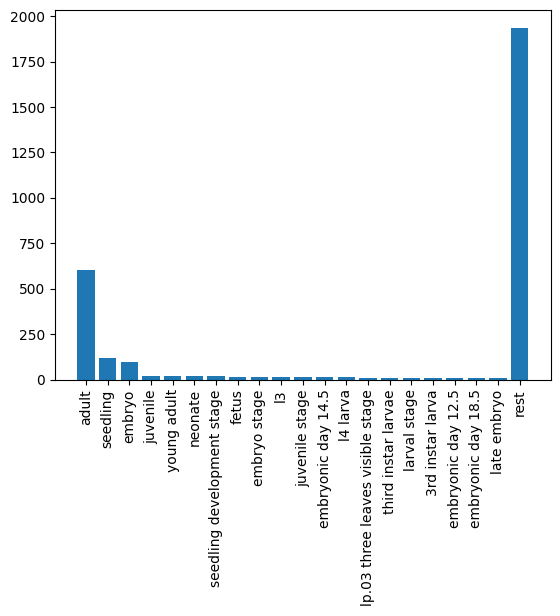

Field name: developmental_stage_0
Select values: [('adult', 605), ('blastocyst', 6), ('stage 3 of female gonad development', 3), ('multiparous cows', 3), ('7.0 mm floret', 2), ('unknown', 2), ('11 days after silk emergence', 2), ('4cell', 1), ('oogenesis stage 14', 1), ('4th instar 12h biololgical replicate 3', 1), ('20 days after transplanting', 1), ('carnegie stage 16-18', 1), ('64-cell st8', 1), ('early maturation green 25-50 mg', 1), ('neonatal (p2)', 1), ('early morula', 1), ('0-2 h embryo', 1), ('embryos 17-18h after egg laying', 1), ('inflorescence stage g', 1), ('p1 (newborn)', 1), ('mixed sex adult', 1), ('yong adult', 1), ('25', 1), ('young (2 months)', 1), ('1.5-2 hours post fertilization', 1), ('third trimester', 1), ('newly molted young adult hermaphrodite', 1), ('mature rosette stage', 1), ('esc passage 5', 1), ('28', 1)]
Number of values: 2987
number of datasets with this field:    1716
number of unique values:               1368
dtype: int64


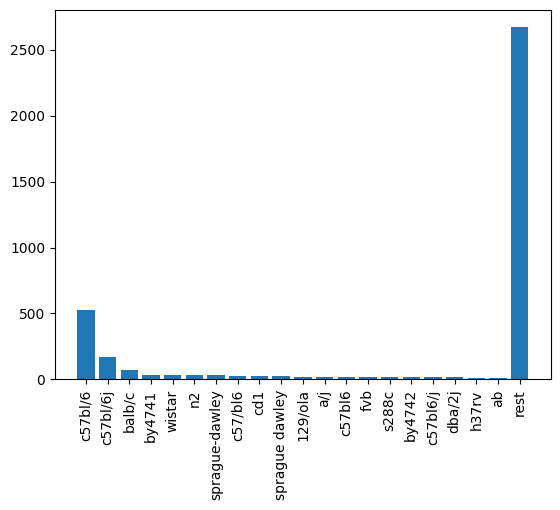

Field name: strain_1
Select values: [('c57bl/6', 526), ('goto-kakizaki', 4), ('mice were of mixed background with c57bl6/129sv contribution (75:25)', 3), ('h.pylori 488_kx1', 2), ('c57bl6/sjl', 2), ('ju1930', 2), ('b856', 1), ('vc16', 1), ('phatthalung', 1), ('b6d2f1j', 1), ('k10', 1), ('clib 89', 1), ('y', 1), ('f344*bn', 1), ('mssa476', 1), ('gmr-gal4; uas-ar x limpet duplication', 1), ('r1_20', 1), ('xanthi nn', 1), ('hxb21', 1), ('iso1', 1), ('cbs767', 1), ('ju263', 1), ('fvb.cg-smn1tm1hung tg(smn2)2hung/j', 1), ('gransden (gdgfp)', 1), ('hh1320', 1), ('cba/ca�c57bl/10 cross', 1), ('zdf', 1), ('f1: 129s1/casteij x 129s2', 1), ('yfr551', 1), ('c57bl6 (b6) mice', 1)]
Number of values: 3819
number of datasets with this field:    2305
number of unique values:               2027
dtype: int64


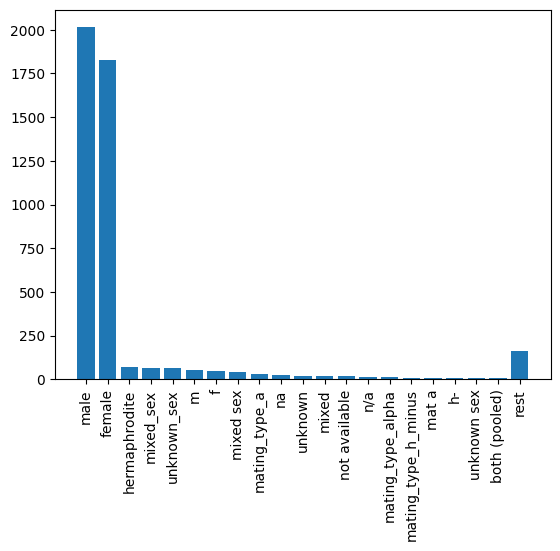

Field name: sex_2
Select values: [('male', 2014), ('m', 51), ('unknown', 21), ('mating_type_h_minus', 10), ('-', 5), ('woman', 4), ('males', 3), ('f?', 2), ('male/female', 2), ('not applicable', 2), ('male or female', 2), ('gram positive', 2), ('0', 1), ('mating type minus', 1), ('female (gfp positive)', 1), ('mixed (2 female, 1 male)', 1), ('mating_type_alpha/alpha', 1), ('females and males', 1), ('castrated male', 1), ('gender not available', 1), ('unk', 1), ('male and female (pooled sample)', 1), ('mc', 1), ('indeterminante', 1)]
Number of values: 4525
number of datasets with this field:    3024
number of unique values:                120
dtype: int64


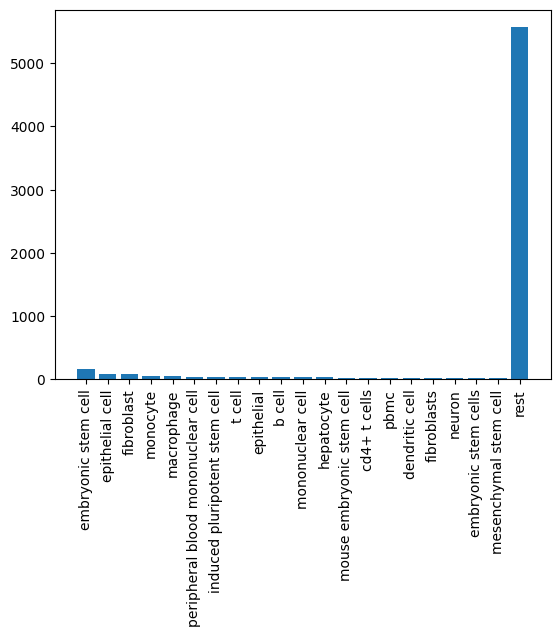

Field name: cell_type_3
Select values: [('embryonic stem cell', 165), ('ipscs', 5), ('glial cell', 4), ('pancreatic islet', 3), ('adult thymic dn3', 2), ('lens epithelial cell line', 2), ('tissue', 2), ('total naive thymocytes', 2), ('hipscs-derived neurons', 1), ('chronic myeloid leukemia progenitor', 1), ('bone marrow msc', 1), ('muscle cell', 1), ('airway smooth muscle cell', 1), ('rag+ b lineage cell', 1), ('er+, pr+/-, her2-', 1), ('cervical epithelial cell line, hela derivative', 1), ('rag1-/- pro-b cells', 1), ('foetal foreskin fibroblast', 1), ('oral immortal keratinocyte, treated for 7 months', 1), ('embryonic stem (es)', 1), ('foreskin fibroblast cell', 1), ('differentiated embryonic stem cells', 1), ('b lymphocyte', 1), ('neuroblasts', 1), ('laser microdissected epithelial cells from end bud of embryonic salivary gland', 1), ('na�ve foxp3-negative cd4+ t cells', 1), ('cultured mouse neuron', 1), ('h929 methylated dna fraction', 1), ('proliferative zone chondrocytes', 1), ('i

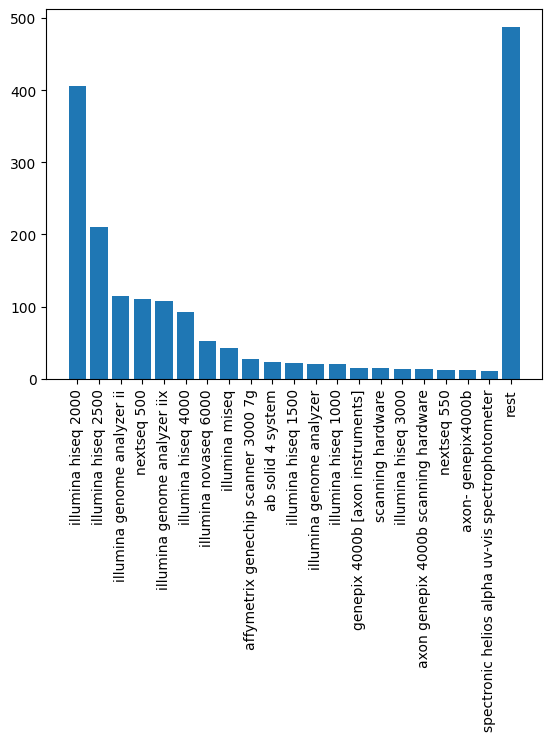

Field name: hardware_4
Select values: [('illumina hiseq 2000', 406), ('illumina hiseq 1500', 22), ('418 [affymetrix]', 10), ('ion torrent pgm', 5), ('-', 4), ('solexa 1g genome analyzer', 4), ('the agilent scanner g2565ba', 3), ('genechip scanner 3000 [affymetrix]', 3), ('agilent surescan high resolution dna microarray scanner', 2), ('anaerobic workstation with airlock', 2), ('10x machine', 2), ('dell poweredge r820', 2), ('generation iii scanner', 1), ('covaris s2', 1), ('g2505b dna microarray scanner', 1), ('affymetrix rat genome 230 2.0', 1), ('macs (automacs, miltenyi biotec)', 1), ('g2505a dna microarray scanner [agilent]', 1), ('genepix 4000b [axon]', 1), ('affymetrix array scanner', 1), ('agilent technologies microarray scanner', 1), ('10x chromium controller', 1), ('eppendorf epmotion 5073m pipetting robot', 1), ('generation iii array scanner [amersham]', 1), ('rneasy plant mini kit (qiagen)', 1), ('illumina genome analyser ii', 1), ('10x genomics chromium single cell kit', 1),

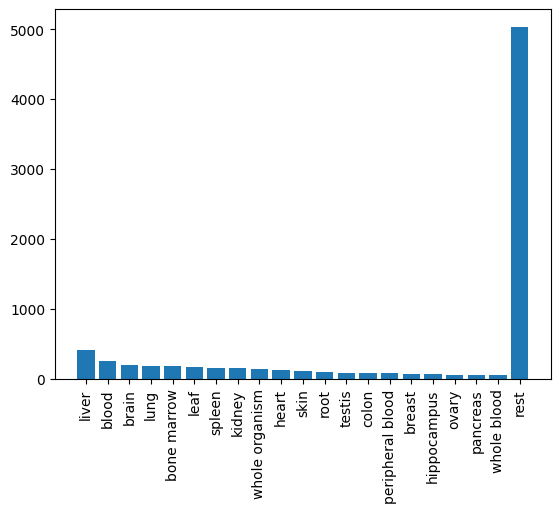

Field name: organism_part_5
Select values: [('liver', 415), ('epithelium of small intestine', 12), ('brown adipose tissue (bat)', 5), ('cornea', 4), ('umbilical vein', 3), ('hindlimb bud', 2), ('whole liver', 2), ('stamen', 2), ('leaf rachis', 2), ('squamous cell carcinoma', 2), ('facial tumor', 1), ('normal tissue from patient 404', 1), ('nasopharyngeal carcinoma', 1), ('caudal neural tube', 1), ('l5_drg', 1), ('cranial neural crest explant', 1), ('abdomen and thorax', 1), ('tendril', 1), ('cutaneous scc', 1), ('mouth mucosa', 1), ('shell of nucleus accumbens', 1), ('small flower buds', 1), ('auricular nerve', 1), ('cystic ebs', 1), ('hematopoietic stem cell', 1), ('mid-tailbud (mtb1)', 1), ('ilc breast cancer cell line ocubf', 1), ('caryopsis', 1), ('hippocampus proper', 1), ('ovarian surface epithelium', 1)]
Number of values: 7781
number of datasets with this field:    4773
number of unique values:               2388
dtype: int64


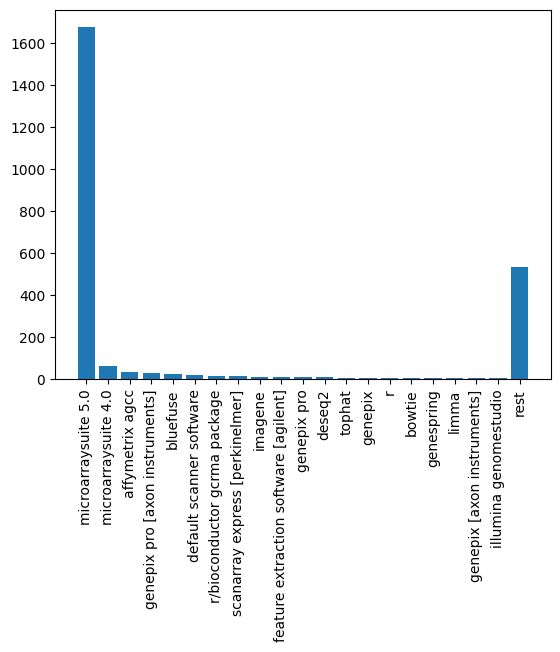

Field name: software_6
Select values: [('microarraysuite 5.0', 1676), ('genepix', 8), ('none', 5), ('star v2.7.3a', 4), ('zumis 2.8.0', 3), ('macs2', 2), ('perl and r scripts', 2), ('illumina', 2), ('tophat2 version 2.0.10', 2), ('macs2 v2.2.6, chipseeker v1.2, featurecounts v1.6.5, deseq2 v1.24', 1), ('affy bioconductor package', 1), ('deseq, edger, noiseq', 1), ('chas', 1), ('agilent g4450aa feature extraction software', 1), ('bowtie version 0.12.9', 1), ('illumina beadstudioâ®', 1), ('bwa, picard tools, gatk, mutect', 1), ('feature extraction software (version 10.7.1.1)', 1), ('partek gs 6.6', 1), ('arraystar', 1), ('genepix, ms excel', 1), ('cuffdiff2', 1), ('robust multi-array analysis', 1), ('flash version 1.2.6', 1), ('deseq function - r studio', 1), ('trimmomatic v0.32; bowtie2 v2.2.3; samtools v0.1.19', 1), ('salmon v0.14.1', 1), ('inimotif', 1), ('feature extraction software version 10.5.1.1', 1)]
Number of values: 2517
number of datasets with this field:    1384
number of un

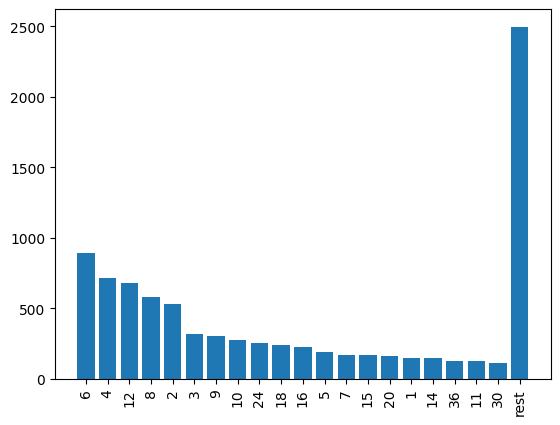

Field name: assay_count_7
Select values: [('6', 891), ('7', 169), ('21', 76), ('33', 32), ('96', 21), ('49', 15), ('88', 11), ('61', 9), ('114', 7), ('91', 6), ('177', 5), ('184', 4), ('462', 3), ('189', 3), ('1449', 3), ('154', 2), ('249', 2), ('679', 2), ('1430', 2), ('531', 1), ('350', 1), ('823', 1), ('1696', 1), ('440', 1), ('312', 1), ('217', 1), ('203', 1), ('452', 1), ('218', 1), ('332', 1)]
Number of values: 8853
number of datasets with this field:    8853
number of unique values:                357
dtype: int64


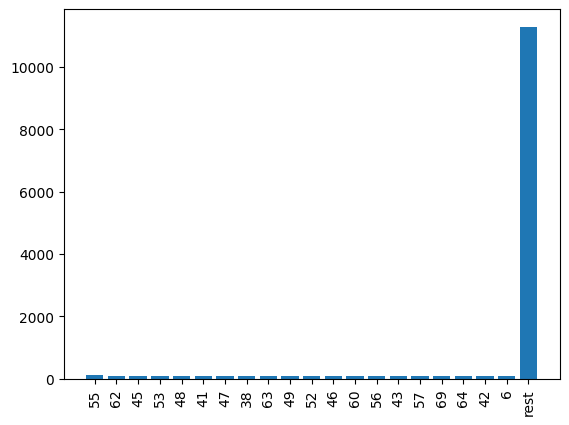

Field name: age_8
Select values: [('55', 107), ('64 year', 35), ('3 months', 15), ('... 18 other values', 8), ('e17.5', 5), ('27 hours post fertilisation', 4), ('60 d', 3), ('1.8', 2), ('80 day', 2), ('< 4', 2), ('12 hours post fertilisation', 2), ('p0.5', 1), ('2.4 month', 1), ('13 months', 1), ('69 yrs', 1), ('46.56', 1), ('82.4', 1), ('19.7 year', 1), ('postnatal day 14-21', 1), ('59 to 67 year', 1), ('20weeks', 1), ('p28', 1), ('6 seconds', 1), ('22 pcw', 1), ('embryonic day 21 (e21)', 1), ('56.1', 1), ('embryonic 12.5 day', 1), ('p17', 1), ('embryo (1 day pre-birth)', 1), ('3 to 6 weeks', 1)]
Number of values: 12907
number of datasets with this field:    3051
number of unique values:               2847
dtype: int64


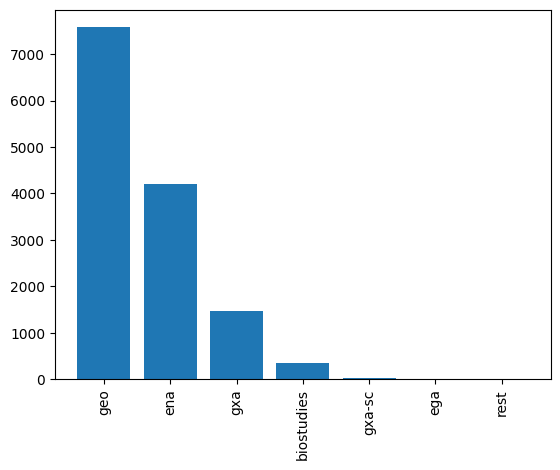

Field name: type_9
Select values: [('geo', 7577), ('ena', 4207), ('gxa', 1461), ('biostudies', 359), ('gxa-sc', 34), ('ega', 1)]
Number of values: 13639
number of datasets with this field:    12008
number of unique values:                   6
dtype: int64


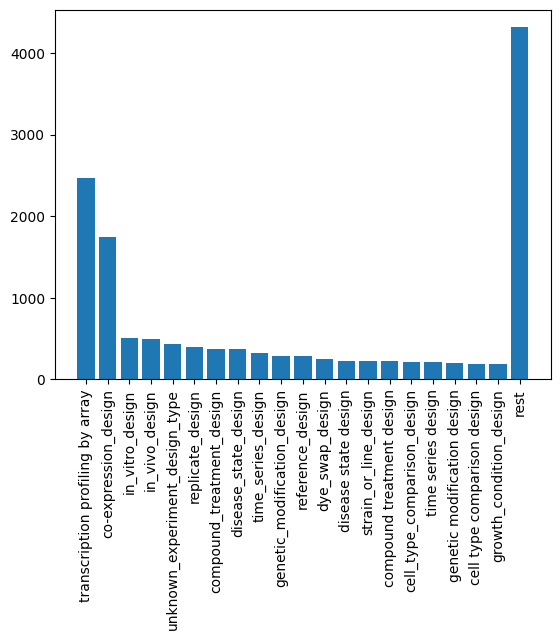

Field name: experimental_designs_10
Select values: [('transcription profiling by array', 2463), ('genetic_modification_design', 290), ('cell type comparison design', 192), ('comparative genomic hybridization by array', 135), ('all_pairs', 96), ('is_expressed_design', 50), ('clinical_history_design', 33), ('stimulated_design_type', 27), ('validation by reverse transcription pcr design', 19), ('clinical history design', 12), ('optimization design', 9), ('cell component comparison design', 6), ('disease_state_design, ex_vivo_design, loop_design, co-expression_design', 4), ('disease_state_design, replicate_design, co-expression_design', 3), ('cell cycle design', 3), ('faire-seq', 2), ('cell_type_comparison_design, development_or_differentiation_design, organism_part_comparison_design, ex_vivo_design, co-expression_design', 2), ('strain_abundance_design', 2), ('transcription profiling of skeletal muscle after gene transfer by electroporation', 1), ('co-expression_design, genetic_modificatio

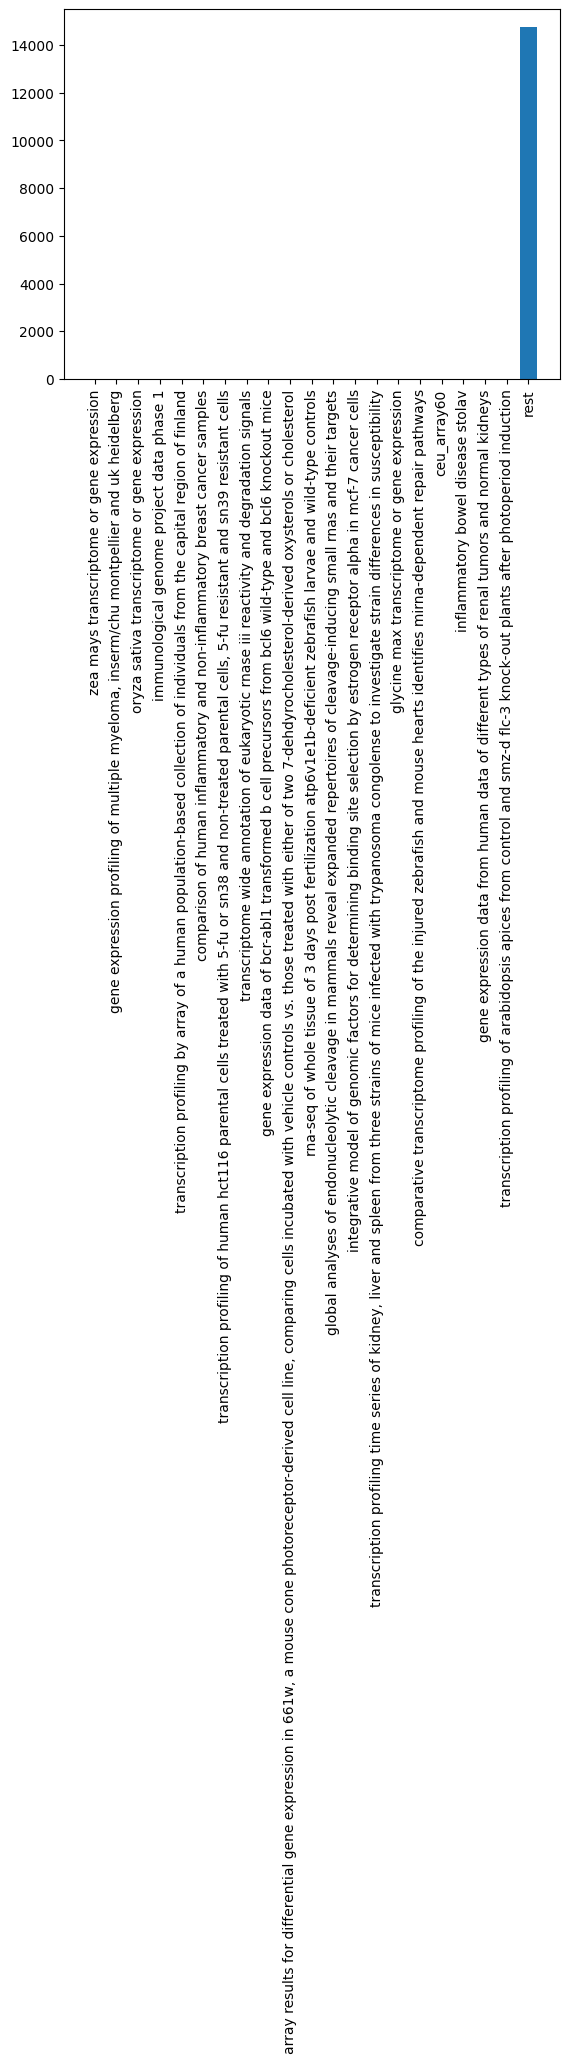

Field name: title_11
Select values: [('zea mays transcriptome or gene expression', 10), ('rna-seq analysis of an apical meristem time series reveals a critical point in arabidopsis thaliana flower initiation', 1), ('expression data from virus-specific mouse th1 and tfh cd4 t cell subsets after lcmv infection', 1), ('characterisation of transcriptional changes in the spinal cord of the progressive experimental autoimmune encephalomyelitis abh mouse model by rna sequencing', 1), ('sirt1 redistribution on chromatin promotes genome stability but alters gene expression during aging', 1), ('prolactin induced murine mammary carcinomas with different estrogen receptor status', 1), ('ribo-seq of hek293t overexpressing wt and g240r gars', 1), ('transcription profiling by array of 4t1 murine breast carcinoma cells and derived cell lines resistant to photodynamic therapy induced by novel porphyrin-based photosensitizers and temoporfin', 1), ('transcription profiling of mouse embryonic stem cells c

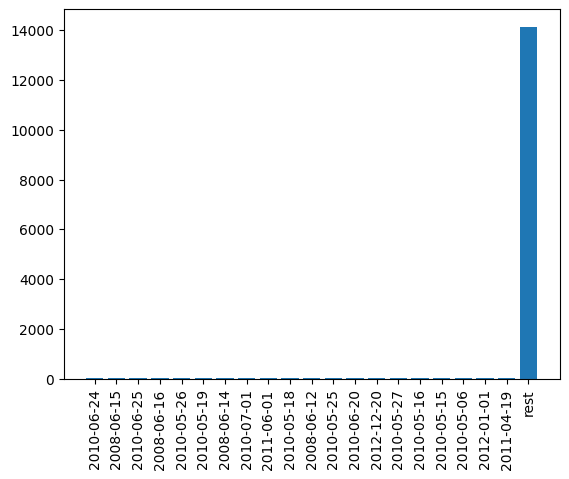

Field name: releasedate_12
Select values: [('2010-06-24', 60), ('2014-02-27', 15), ('2015-02-27', 11), ('2015-05-20', 10), ('2014-08-05', 8), ('2010-09-15', 7), ('2013-12-06', 7), ('2013-01-01', 6), ('2011-07-31', 5), ('2012-03-13', 5), ('2010-10-30', 5), ('2015-09-23', 4), ('2011-08-26', 4), ('2016-04-22', 3), ('2011-03-11', 3), ('2013-02-10', 3), ('2008-02-23', 2), ('2018-07-04', 2), ('2018-06-20', 2), ('2009-04-03', 2), ('2011-12-14', 2), ('2009-08-18', 1), ('2005-10-14', 1), ('2019-02-04', 1), ('2013-05-04', 1), ('2010-10-29', 1), ('2009-12-08', 1), ('2021-11-05', 1), ('2018-05-08', 1), ('2012-03-10', 1)]
Number of values: 14844
number of datasets with this field:    14844
number of unique values:                3427
dtype: int64


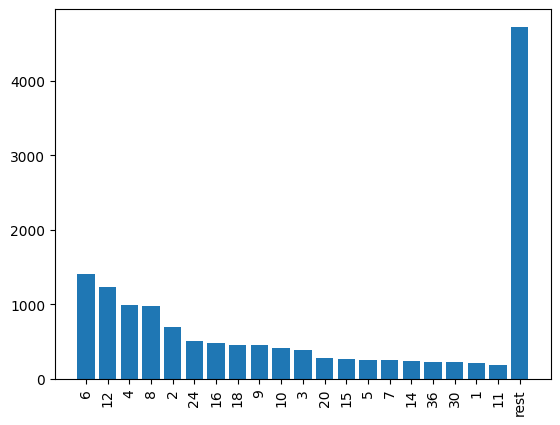

Field name: sample_count_13
Select values: [('6', 1399), ('30', 227), ('60', 70), ('54', 43), ('78', 25), ('86', 15), ('132', 12), ('113', 9), ('111', 7), ('232', 6), ('170', 5), ('169', 4), ('244', 3), ('278', 3), ('284', 3), ('1019', 2), ('474', 2), ('424', 2), ('1415', 2), ('194', 1), ('1248', 1), ('854', 1), ('341', 1), ('562', 1), ('828', 1), ('632', 1), ('670', 1), ('475', 1), ('368', 1)]
Number of values: 14844
number of datasets with this field:    14844
number of unique values:                 480
dtype: int64


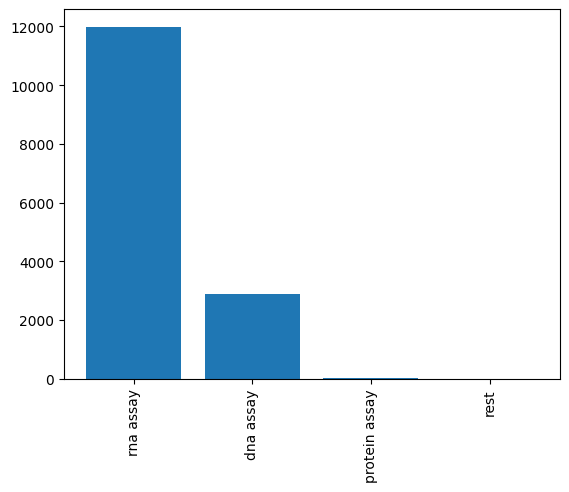

Field name: assay_by_molecule_14
Select values: [('rna assay', 11991), ('dna assay', 2882), ('protein assay', 39)]
Number of values: 14912
number of datasets with this field:    14344
number of unique values:                   3
dtype: int64


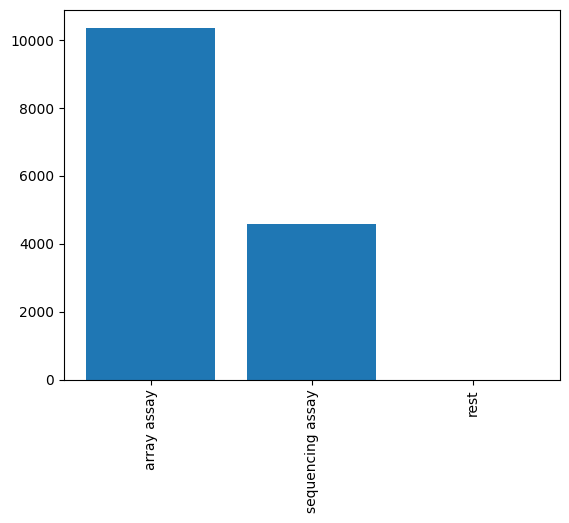

Field name: technology_15
Select values: [('array assay', 10371), ('sequencing assay', 4594)]
Number of values: 14965
number of datasets with this field:    14783
number of unique values:                   2
dtype: int64


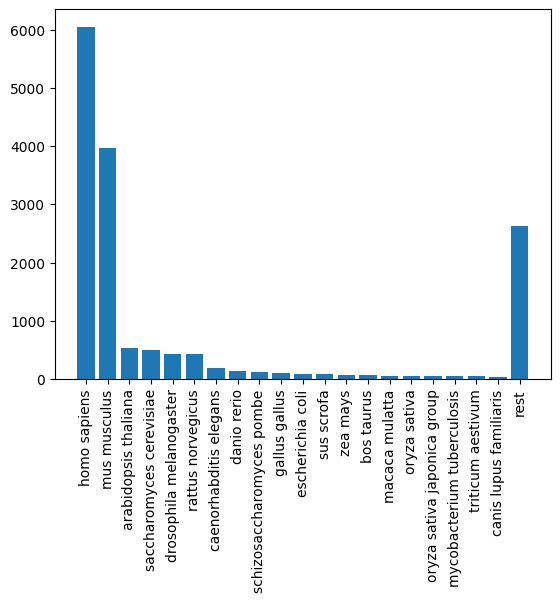

Field name: organism_16
Select values: [('homo sapiens', 6045), ('hordeum vulgare', 21), ('yarrowia lipolytica', 10), ('streptomyces coelicolor a3(2)', 7), ('bordetella pertussis', 5), ('phallusia mammillata', 4), ('phytophthora infestans', 3), ('mycobacterium avium subsp. paratuberculosis', 3), ('panicum virgaturm', 2), ('mus musculus x mus spretus', 2), ('rhodobacter sphaeroides 2.4.1', 2), ('ursus americanus', 2), ('pseudomonas syringae pv. phaseolicola', 2), ('pantherophis obsoletus lindheimeri', 1), ('southern bean mosaic virus', 1), ('chenopodium amaranticolor', 1), ('spodoptera frugiperda', 1), ('oryzias latipes', 1), ('calyptogena pacifica gill symbiont', 1), ('coccidioides immitis rs', 1), ('escherichia coli str. k-12 substr. mg1661', 1), ('triticum turgidum subsp. dicoccoides', 1), ('petaurus breviceps', 1), ('saccharomyces paradoxus nrrl y-17217', 1), ('drosophila serrata', 1), ('mycobacterium marinum', 1), ('microtus duodecimcostatus', 1), ('paracoccidioides brasiliensis pb

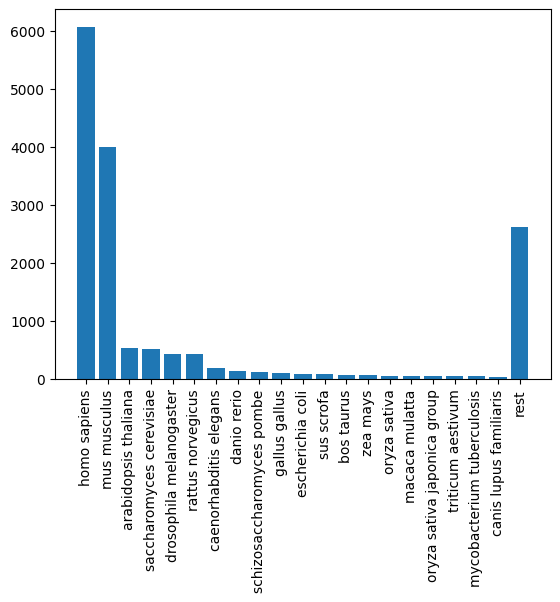

Field name: organism_17
Select values: [('homo sapiens', 6066), ('ovis aries', 22), ('canis familiaris', 10), ('carassius auratus', 7), ('magnaporthe oryzae', 5), ('solenopsis invicta', 4), ('bacillus anthracis', 3), ('sulfolobus acidocaldarius', 3), ('pongo abelii', 2), ('listeria monocytogenes egd', 2), ('trypanosoma cruzi', 2), ('saccharum hybrid cultivar (mixed)', 2), ('dicentrarchus labrax', 2), ('poncirus trifoliata', 1), ('echinococcus granulosus', 1), ('musca domestica', 1), ('environmental samples', 1), ('soil metagenome', 1), ('heliconius melpomene melpomene', 1), ('anthurium andraeanum', 1), ('miscanthus x giganteus', 1), ('acropora millepora', 1), ('suncus murinus', 1), ('ectocarpus fasciulatus', 1), ('siniperca chuatsi', 1), ('mycobacterium phage giles', 1), ('schizosaccharomyces japonicus', 1), ('lachancea kluyveri nrrl y-12651', 1), ('cucurbita moschata', 1), ('parasteatoda tepidariorum', 1)]
Number of values: 15767
number of datasets with this field:    14792
number of 

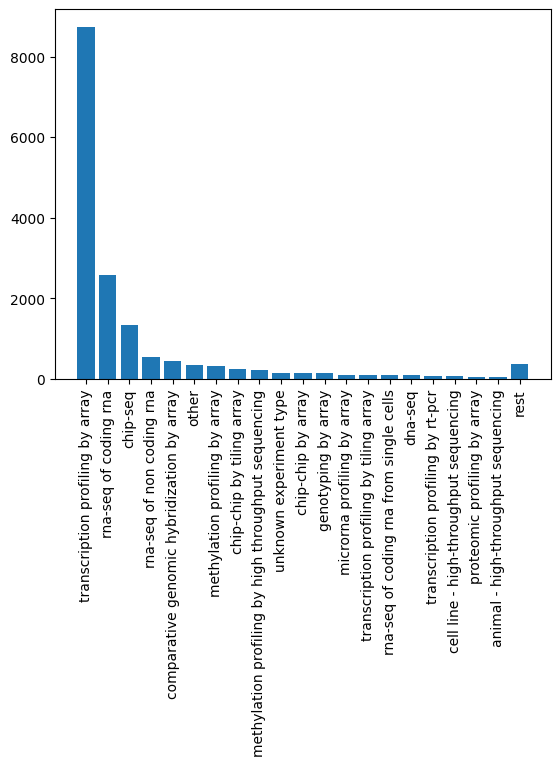

Field name: study_type_18
Select values: [('transcription profiling by array', 8735), ('rna-seq of non coding rna', 533), ('methylation profiling by array', 326), ('unknown experiment type', 157), ('microrna profiling by array', 108), ('dna-seq', 89), ('proteomic profiling by array', 39), ('high-throughput sequencing', 24), ('baseline', 17), ('cell line - one-color microarray', 15), ('differential', 13), ('rip-seq', 10), ('one-color microarray', 9), ('medip-seq', 7), ('human - single-cell sequencing', 6), ('trajectory', 5), ('mnase-seq', 4), ('scatac-seq', 4), ('4c', 3), ('transcription profiling by mpss', 3), ('human - methylation microarray', 2), ('genotyping by mass spectrometer', 1), ('spatial transcriptomics by high-throughput sequencing', 1), ('fix: ? by tiling array', 1)]
Number of values: 16183
number of datasets with this field:    14797
number of unique values:                  70
number of ontologies refered:              1
number of unique ontology terms:          42
dtype:

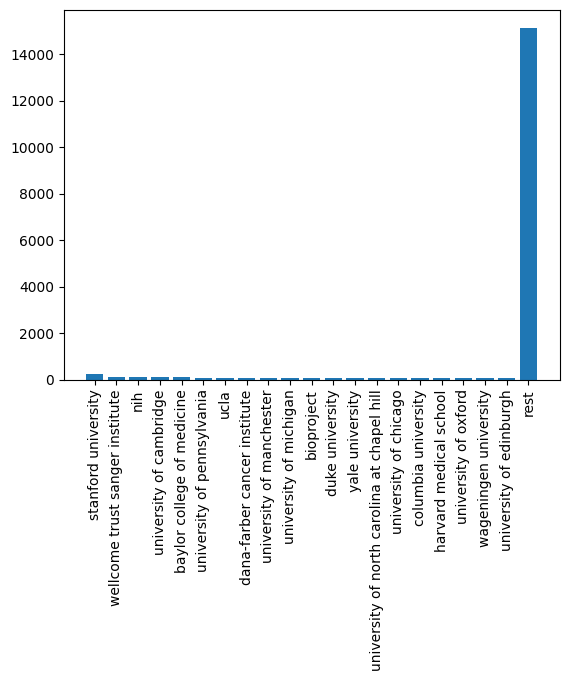

Field name: name_19
Select values: [('stanford university', 235), ('flanders institute for biotechnology (vib)', 16), ('vrije universiteit medical center', 9), ('peter maccallum cancer centre', 6), ('turku centre for biotechnology', 5), ('university of pennsylvania school of medicine', 4), ('biotech research and innovation centre', 3), ('1center for cancer biomarkers, department of clinical science, university of bergen, 5020 bergen, norway 2department of gynecology and obstetrics, haukeland university hospital, 5021 bergen, norway 3department of microbiology, haukeland university hospital, 5021 bergen, norway 4computational biology unit, university of bergen, 5020 bergen, norway  5center for cancer biomarkers, department of clinical medicine, university of bergen, 5020 bergen, norway 6department of pathology, haukeland university hospital, 5021 bergen, norway 7breast cancer research group, centre for molecular medicine norway, university of oslo, 0318 oslo, norway', 3), ('ubc - icaptu

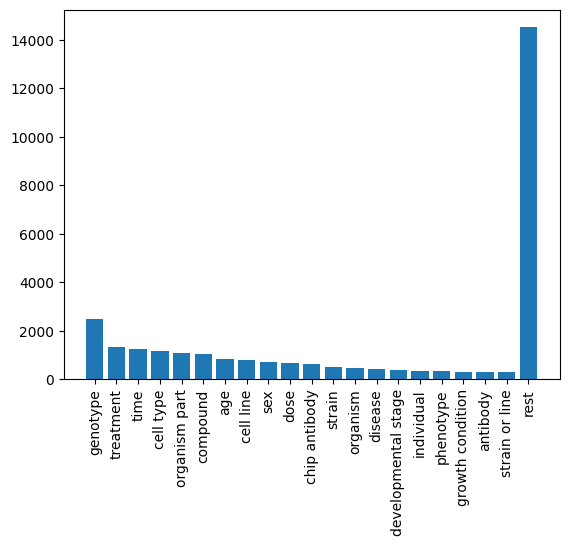

Field name: experimental_factors_20
Select values: [('genotype', 2502), ('materialtype', 17), ('debulking', 6), ('disease_stage', 4), ('single cell library construction', 3), ('data set', 3), ('cell line derived from gem model of prostate cancer', 2), ('survival time (years)', 2), ('chip/dip antibody', 2), ('esr1_status', 2), ('hormone status', 1), ('orally gavaged (for 3 days)', 1), ('treated at', 1), ('plant genotype', 1), ('sheep id', 1), ('gfp positive?', 1), ('c3 dose', 1), ('time stimulated with anti-igm', 1), ('months from dg to r', 1), ('tic class', 1), ('line ab', 1), ('cycle phase/ gestational age', 1), ('dlda30 prediction', 1), ('inoculation', 1), ('final order', 1), ('ageaccelerationdsvscontrolsotherregions', 1), ('inpp4b mrna', 1), ('time point h', 1), ('lot #', 1), ('mutation_hgvs', 1)]
Number of values: 29857
number of datasets with this field:    13067
number of unique values:                4458
dtype: int64


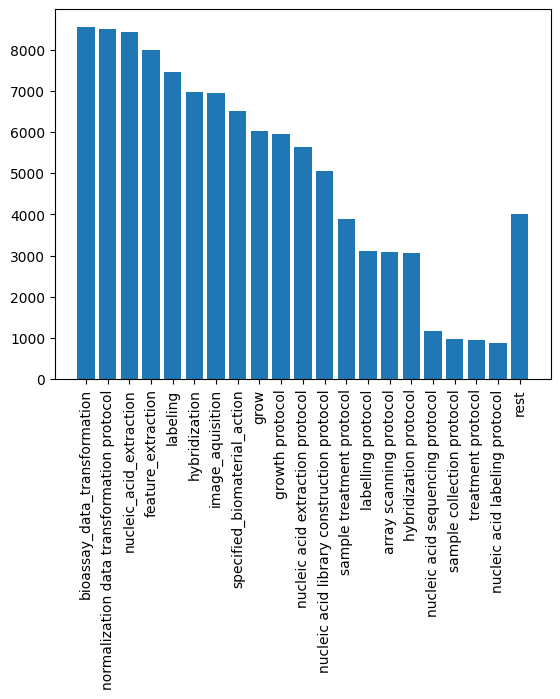

Field name: type_21
Select values: [('bioassay_data_transformation', 8559), ('growth protocol', 5957), ('treatment protocol', 947), ('dissection protocol', 84), ('unknown_protocol_type', 23), ('purify', 15), ('incubate', 10), ('acclimatization', 7), ('normalization data transformation', 5), ('data acquisition', 4), ('gene expression protocol', 3), ('nucleic_acid_extraction by iclip', 3), ('maternal diet', 2), ('peak_calling', 2), ('starvation', 2), ('strain construction', 2), ('bioassay_data_transformation 4', 1), ('array hybridisation', 1), ('nucleic acid hybridization to array protoocol', 1), ('array scanning', 1), ('hybridizaiton', 1), ('cgh normalization data transformation protocol', 1), ('normalization data', 1), ('image_analysis', 1), ('treatment_protocol', 1), ('standard affymetrix hybridization protoclols', 1), ('agilent scanning', 1), ('nucelic_acid_extraction', 1)]
Number of values: 105207
number of datasets with this field:    14751
number of unique values:                 

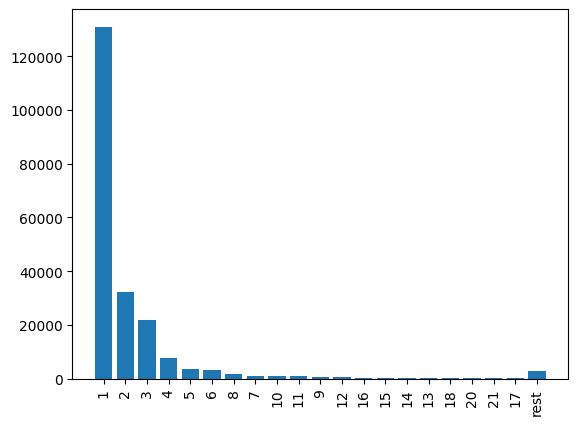

Field name: no._of_samples_22
Select values: [('1', 130938), ('9', 769), ('24', 142), ('96', 63), ('41', 37), ('45', 24), ('55', 17), ('72', 14), ('62', 10), ('113', 8), ('86', 6), ('328', 5), ('126', 4), ('314', 3), ('264', 3), ('246', 2), ('293', 2), ('140', 2), ('363', 2), ('403', 2), ('242', 1), ('189', 1), ('239', 1), ('523', 1), ('299', 1), ('170', 1), ('219', 1), ('274', 1), ('421', 1)]
Number of values: 209877
number of datasets with this field:    11833
number of unique values:                 284
dtype: int64


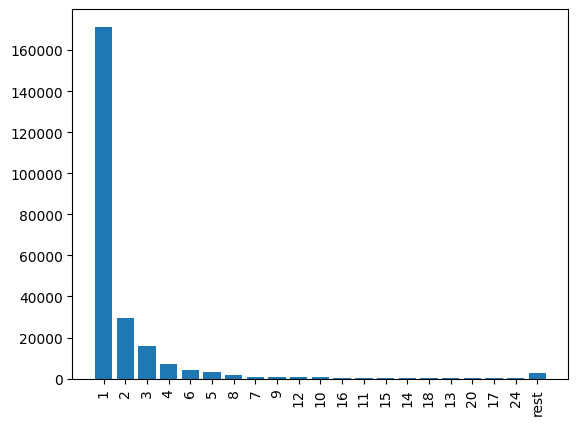

Field name: no._of_samples_23
Select values: [('1', 171369), ('10', 846), ('21', 165), ('27', 68), ('31', 41), ('49', 26), ('47', 19), ('94', 13), ('91', 9), ('75', 7), ('98', 6), ('124', 4), ('167', 3), ('226', 3), ('139', 3), ('340', 2), ('286', 2), ('513', 2), ('198', 2), ('117', 2), ('298', 1), ('195', 1), ('362', 1), ('216', 1), ('343', 1), ('184', 1), ('304', 1), ('229', 1)]
Number of values: 242150
number of datasets with this field:    11182
number of unique values:                 279
dtype: int64


In [19]:

for field in dfs:
    df = dfs[field]
    commons = Counter(df["value"]).most_common(20)
    commons = {t[0]:t[1] for t in commons}
    commons["rest"] = len(df)-sum(commons.values())
    plt.bar(commons.keys(), commons.values())
    plt.xticks(rotation=90)

    plt.show()

    commons = Counter(df["value"]).most_common()
    f = len(commons)//30+1

    print("Field name:", field)
    print("Select values:", commons[::f])
    print("Number of values:", len(df))
    print(df.rename(columns={
            "id":"number of datasets with this field:",
            "value":"number of unique values:",
            "ont": "number of ontologies refered:",
            "ont_term":"number of unique ontology terms:"
            }).nunique())


# ontology fields

In [34]:

for field in dfs:
    df = dfs[field]


    if len(df.columns) > 2:
        print("Field name:", field)
        print("Number of values:", len(df))
        print(df.dropna(subset="ont_term").rename(columns={
                "id":"number of datasets with ontology term:",
                "value":"number of unique values with ontology term:",
                "ont": "number of ontologies refered:",
                "ont_term":"number of unique ontology terms:"
                }).nunique())
        print(df.dropna(subset="ont_term").drop("id", axis=1).drop_duplicates(subset = ["value", "ont_term"]))


Field name: experimental_designs_10
Number of values: 13944
number of datasets with ontology term:         28
number of unique values with ontology term:    15
number of ontologies refered:                   1
number of unique ontology terms:               17
dtype: int64
                                       value  ont     ont_term
277                  growth condition design  efo  efo:0001759
564                compound treatment design  efo  efo:0001755
962                       time series design  efo  efo:0001779
963                stimulus or stress design  efo  efo:0001762
2212                   strain or line design  efo  efo:0001754
2213   development or differentiation design  efo  efo:0001746
2258                 population based design  efo  efo_0001430
2259               operator variation design  efo  efo_0001772
3672                        reference design  efo  efo_0001775
3673                    observational design  efo  efo_0000629
4737             cell type compari

## not one-to-one relationship between value and ontology term

In [37]:
uniques_21 = dfs["type_21"].dropna(subset="ont_term").drop_duplicates(subset = ["value", "ont_term"])
uniques_21

,id,value,ont,ont_term
381,26084880___E-MTAB-4202,nucleic acid sequencing protocol,efo,efo_0004170
382,26084880___E-MTAB-4202,nucleic acid library construction protocol,efo,efo_0004184
464,26883361___E-MTAB-3807,nucleic acid extraction protocol,efo,efo_0002944
465,26883361___E-MTAB-3807,high throughput sequence alignment protocol,efo,efo_0004917
466,26883361___E-MTAB-3807,sample collection protocol,efo,efo_0005518
478,33770499___E-MTAB-7838,nucleic acid labeling protocol,efo,efo_0003813
481,33770499___E-MTAB-7838,normalization data transformation protocol,efo,efo_0003816
484,33770499___E-MTAB-7838,nucleic acid hybridization to array protocol,efo,efo_0003815
489,33770499___E-MTAB-7838,growth protocol,efo,efo_0003789
490,33770499___E-MTAB-7838,treatment protocol,efo,efo_0003969


In [42]:
# diferent ont_terms for same value
uniques_21[uniques_21["value"] == "growth protocol"]

,id,value,ont,ont_term
489,33770499___E-MTAB-7838,growth protocol,efo,efo_0003789
20984,25753420___E-MTAB-3104,growth protocol,efo,protocoltype\tefo\tnull\tgrowth protocol


In [43]:
# different value for same ont_term
uniques_21[uniques_21["ont_term"] == "efo_0003789"]

,id,value,ont,ont_term
489,33770499___E-MTAB-7838,growth protocol,efo,efo_0003789
4888,30567555___E-MTAB-5903,sample collection protocol,efo,efo_0003789


In [49]:
# ont_term specified with eiter ":" or "_"
pd.concat([
    uniques_21[uniques_21["ont_term"] == "efo_0003789"],
    uniques_21[uniques_21["ont_term"] == "efo:0003789"]
])
    


,id,value,ont,ont_term
489,33770499___E-MTAB-7838,growth protocol,efo,efo_0003789
4888,30567555___E-MTAB-5903,sample collection protocol,efo,efo_0003789
67145,30835057___E-MTAB-7748,growth,efo,efo:0003789


## plot distribution, like before, but only datasets with ontology terms

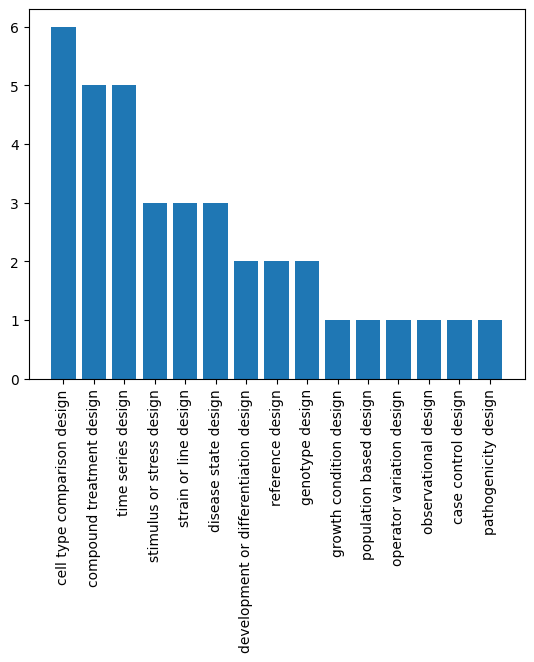

Field name: experimental_designs_10
ALL values [('cell type comparison design', 6), ('compound treatment design', 5), ('time series design', 5), ('stimulus or stress design', 3), ('strain or line design', 3), ('disease state design', 3), ('development or differentiation design', 2), ('reference design', 2), ('genotype design', 2), ('growth condition design', 1), ('population based design', 1), ('operator variation design', 1), ('observational design', 1), ('case control design', 1), ('pathogenicity design', 1)]
Number of values: 37
number of datasets with ontology term:         28
number of unique values with ontology term:    15
number of ontologies refered:                   1
number of unique ontology terms:               17
dtype: int64


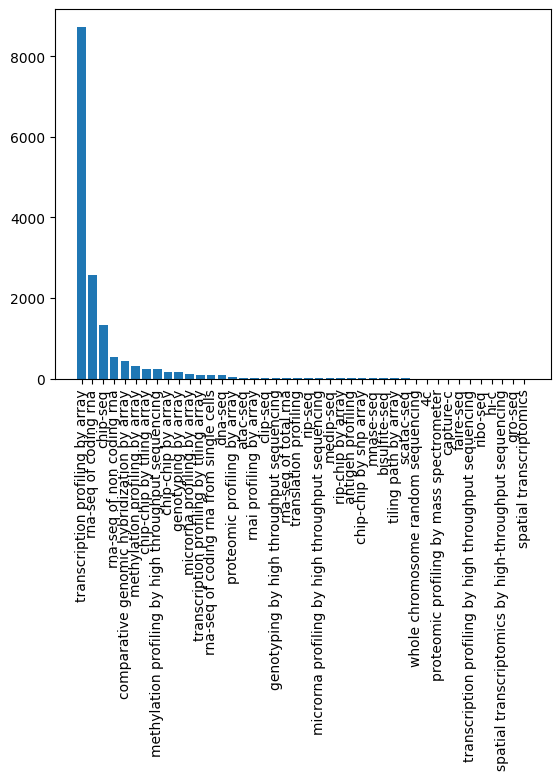

Field name: study_type_18
ALL values [('transcription profiling by array', 8732), ('rna-seq of coding rna', 2562), ('chip-seq', 1326), ('rna-seq of non coding rna', 532), ('comparative genomic hybridization by array', 447), ('methylation profiling by array', 326), ('chip-chip by tiling array', 241), ('methylation profiling by high throughput sequencing', 233), ('chip-chip by array', 154), ('genotyping by array', 153), ('microrna profiling by array', 108), ('transcription profiling by tiling array', 100), ('rna-seq of coding rna from single cells', 91), ('dna-seq', 89), ('proteomic profiling by array', 39), ('atac-seq', 17), ('rnai profiling by array', 17), ('clip-seq', 16), ('genotyping by high throughput sequencing', 15), ('rna-seq of total rna', 14), ('translation profiling', 12), ('rip-seq', 10), ('microrna profiling by high throughput sequencing', 9), ('medip-seq', 7), ('rip-chip by array', 6), ('antigen profiling', 4), ('chip-chip by snp array', 4), ('mnase-seq', 4), ('bisulfite-s

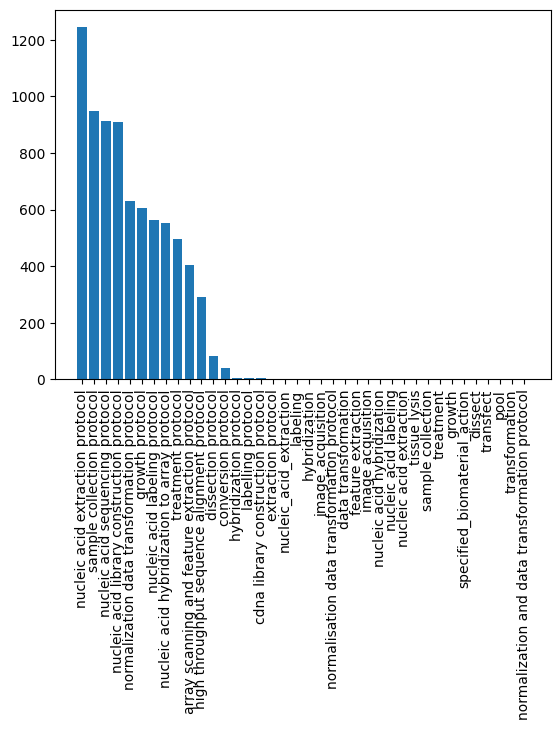

Field name: type_21
ALL values [('nucleic acid extraction protocol', 1244), ('sample collection protocol', 948), ('nucleic acid sequencing protocol', 914), ('nucleic acid library construction protocol', 908), ('normalization data transformation protocol', 630), ('growth protocol', 604), ('nucleic acid labeling protocol', 563), ('nucleic acid hybridization to array protocol', 554), ('treatment protocol', 496), ('array scanning and feature extraction protocol', 404), ('high throughput sequence alignment protocol', 290), ('dissection protocol', 83), ('conversion protocol', 39), ('hybridization protocol', 6), ('labelling protocol', 5), ('cdna library construction protocol', 3), ('extraction protocol', 2), ('nucleic_acid_extraction', 2), ('labeling', 2), ('hybridization', 2), ('image_acquisition', 2), ('normalisation data transformation protocol', 2), ('data transformation', 2), ('feature extraction', 2), ('image acquisition', 2), ('nucleic acid hybridization', 2), ('nucleic acid labeling',

In [54]:

for field in dfs:
    if len(dfs[field].columns) > 2:

        df = dfs[field].dropna(subset="ont_term")
        commons = Counter(df["value"]).most_common(60)
        commons = {t[0]:t[1] for t in commons}
        #commons["rest"] = len(df)-sum(commons.values())
        plt.bar(commons.keys(), commons.values())
        plt.xticks(rotation=90)

        plt.show()

        commons = Counter(df["value"]).most_common()
        f = len(commons)//30+1

        print("Field name:", field)
        print("ALL values", commons)
        print("Number of values:", len(df))
        print(df.rename(columns={
                    "id":"number of datasets with ontology term:",
                    "value":"number of unique values with ontology term:",
                    "ont": "number of ontologies refered:",
                    "ont_term":"number of unique ontology terms:"
                }).nunique())
